# v5 — resep v2 (LB 0.91514) untuk line/block/glyph + **view halaman resolusi tinggi** untuk page

**Temuan EDA round 4** (`eda/21–24`, `prepro/08`, ringkasan di `eda/README.md`):
1. **Page (tinggi asli ≥250 px) = 24.6% test, tapi hanya 5.3% train**, dan OOF v2 paling lemah di sini. Statistik page train ≈ test (JPEG 79% vs 80%, ketajaman 2.92 vs 2.68): page test adalah foto/poster web yang **bersih**, tidak dikorupsi sintetis seperti line (`eda/23`).
2. Di v2, page di-letterbox ke 160×640 sehingga hanya mengisi **33% canvas** dengan tinggi 160 px; huruf sekitar 3.5 px (`eda/21`, `eda/10`). Kesalahan page yang terlihat: bali↔jawa (butuh detail glyph) dan jawi↔pegon (chart "Aksara Pegon", sampul buku).
3. Probe DINOv3 beku, group-CV pada 199 page train (`eda/22`): akurasi page **v2-view .60 → 448² .69 → 640² .73** (F1 .52 → .64 → .69). Warna tidak menambah apa-apa (RGB .68 vs gray .69), preprocessing v2 (crop/stretch) justru −2 poin. View 640 memperbaiki 26 page dan merusak 8; recall jawi .13 → .39, lontara .70 → .90 (`eda/24`).
4. Augmentasi page dikalibrasi supaya tidak membuka gap baru (pelajaran ColorJitter): domain-AUC statistik canvas train-aug vs test page **.475**, setara train-clean .466 (`prepro/08`).

**Satu faktor yang berubah dari v2**
| | v2 | v5 |
|---|---|---|
| line / block / glyph | corrupt → preprocess → 160×640 | **sama persis** |
| page (h≥250) | preprocess → letterbox 160×640 (33% canvas) | **gray mentah → letterbox 640×640** (70% canvas, area ×9), augmentasi foto ringan |
| batch | 16 gambar 160×640 | micro-batch homogen: 16 non-page (400 token) **atau** 4 page (1600 token); ±20% langkah = page |
| validasi page | view v2 terkorupsi | view page **bersih** (seperti page test) |

**Output**
1. `submission_A_v5.csv`: seluruh prediksi v5.
2. `submission_B_hybrid.csv`: non-page dari v2 (LB-proven), page dari v5. Ini **mengisolasi efek page**; butuh `results/v2/main/fold*_test_logits.npy`.

**Cara run di vast.ai (RTX 5090)**: sama seperti v2 (torch ≥2.7 cu128, upload `data/` + `data/folds.csv` + `data/test_train_twins.csv`; opsional `results/v2/main/` untuk submission B). Estimasi ±30–45 menit untuk 5 fold. Fold yang sudah selesai di-skip saat rerun.

In [1]:
%pip install -q "timm>=1.0.27" scikit-learn pandas matplotlib scipy pillow

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os, io, gc, json, math, random, time, platform
from pathlib import Path
from multiprocessing import Pool

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import timm
from timm.optim import param_groups_layer_decay
from torch import nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from PIL import Image
from sklearn.metrics import f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay


def find_root():
    for c in [Path.cwd(), Path.cwd().parent, Path('/workspace/infest-26'), Path('/workspace')]:
        if (c / 'data/train.csv').exists():
            return c
    raise FileNotFoundError('data/train.csv tidak ditemukan - set ROOT manual')


ROOT = find_root()
DATA = ROOT / 'data'

SMOKE_TEST = False            # True: fold 0, 1 epoch
RUN_NAME = 'main'             # output + resume key: results/v5/<RUN_NAME>
SEED = 42
MODEL_NAME = 'vit_large_patch16_dinov3.lvd1689m'
H, W = 160, 640               # eda/07: tinggi tetap 160 -> tinta ~10 patch
EPOCHS, WARMUP_EPOCHS, PATIENCE = 12, 1, 4
MICRO_BATCH, ACCUM = 16, 2    # efektif 32; 5090 32GB muat tanpa grad checkpointing
EVAL_BATCH = 64
GRAD_CKPT = False             # True jika OOM
BASE_LR, HEAD_LR = 4e-5, 3e-4 # BASE_LR = blok teratas; blok bawah dikali LAYER_DECAY^depth
LAYER_DECAY, WEIGHT_DECAY = 0.85, 0.05
LABEL_SMOOTHING = 0.1
NONLINE_BOOST = 1.5           # prepro/03: non-line 41% test vs 21% train
FOLDS = [0, 1, 2, 3, 4]
NUM_WORKERS = max(4, min(28, (os.cpu_count() or 8) - 2))
PAGE_S = 640                  # eda/22: page acc .60 (v2 view) -> .69 (448) -> .73 (640)
PAGE_MB = 4                   # 4 x 1600 token = memori setara 16 x 400 token (line)
PAGE_P = 0.2                  # porsi micro-batch page per epoch (page 5.3% train, 24.6% test)
PAGE_EVAL_BATCH = 16
RAW_MAX_SIDE = 1600           # poster 5000px diperkecil sekali saat cache (canvas tetap 160 tinggi)
USE_TWINS = True              # 17 test near-copy train -> pakai label train
SAVE_WEIGHTS = False          # True: simpan state bf16 per fold (~600MB/fold)
LABELS = ['bali', 'jawa', 'jawi', 'lampung', 'lontara', 'pegon', 'sunda']
LABEL_TO_ID = {l: i for i, l in enumerate(LABELS)}
if SMOKE_TEST:
    EPOCHS, FOLDS, RUN_NAME = 1, [0], 'smoke'

assert torch.cuda.is_available(), 'Butuh GPU CUDA'
DEVICE = torch.device('cuda')
cap = torch.cuda.get_device_capability()
assert cap[0] < 12 or any(a.startswith('sm_12') for a in torch.cuda.get_arch_list()), \
    'torch ini tidak support RTX 5090 (sm_120): pip install -U torch torchvision --index-url https://download.pytorch.org/whl/cu128'
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True
torch.backends.cudnn.benchmark = True


def seed_all(s):
    random.seed(s); np.random.seed(s); torch.manual_seed(s); torch.cuda.manual_seed_all(s)


seed_all(SEED)
OUT = ROOT / 'results' / 'v5' / RUN_NAME
OUT.mkdir(parents=True, exist_ok=True)
print(dict(root=str(ROOT), torch=torch.__version__, timm=timm.__version__, gpu=torch.cuda.get_device_name(),
           capability=cap, cpus=os.cpu_count(), workers=NUM_WORKERS, out=str(OUT)))

{'root': '/workspace', 'torch': '2.11.0+cu128', 'timm': '1.0.29', 'gpu': 'NVIDIA GeForce RTX 5090', 'capability': (12, 0), 'cpus': 16, 'workers': 14, 'out': '/workspace/results/v5/main'}


## Pipeline
Bagian atas **identik dengan v2** (disalin dari `notebooks/v2.ipynb`). Bagian bawah (`letterbox`, `page_eval`, `page_train`) disalin dari `prepro/page_view.py`, yang sudah dicek visual dan numerik di `prepro/08_page_view_check.py`.

In [3]:
"""Preprocessing + augmentation for INFEST aksara classification. Import this from the training notebook.

Order matters:   raw RGB --(train only) corrupt()--> preprocess() --> to_canvas()
corrupt() BEFORE preprocess() because the test corruptions were applied to raw images; the network must
see train images that went through exactly the same normalisation the corrupted test images go through.

Every number below comes from eda/outputs (see eda/README.md):
  rotation +-15 deg          07: test |skew| p95=10, p99=13; 30% of test lines >=3 deg (train 4%)
  tint p=.45                 03: bg_sat>12 in 44% test vs 3% train
  blur/pixelate p=.55        03: sharp<0.6 in 69% test vs 12% train
  occluder p=.12, dashes .15 03 flat_gray 6.6% test (detector under-counts, seen in 02 zoom)
  black bar p=.07            03: black border 7.3% test vs 1.2% train
  jpeg p=.3                  01: JPEG 21% test vs 4.6% train
  canvas H=160 fixed height  07: letterbox 160x640 leaves bali/lontara at ~2 patches of ink
"""
import io
import math
import random

import numpy as np
from PIL import Image, ImageDraw, ImageFilter, ImageOps
from scipy import ndimage as ndi


# ----------------------------------------------------------------------------- load
def load_rgb(path):
    with Image.open(path) as im:
        im = ImageOps.exif_transpose(im)
        if im.mode in ("RGBA", "LA", "P", "PA"):
            im = im.convert("RGBA")
            im = Image.alpha_composite(Image.new("RGBA", im.size, "white"), im)
        return im.convert("RGB")


# ----------------------------------------------------------------------------- deterministic (train + test)
def _otsu(g):
    hist = np.bincount(g.ravel(), minlength=256).astype(float)
    p = hist / hist.sum(); w = np.cumsum(p); mu = np.cumsum(p * np.arange(256))
    return int(np.argmax((mu[-1] * w - mu) ** 2 / (w * (1 - w) + 1e-12)))


def remove_black_fill(g, dark=40, min_contact=0.3, min_solidity=0.9, max_holes=0.03):
    """Solid black regions glued to the border (shift / rotate fill, black bars) -> white.
    A border-touching pure-black component is fill when it has no holes (a real dark background has
    light text inside it) AND either (a) runs along >=min_contact of a side or (b) is near-convex
    (rotation corner triangle). Glyph-sized images (both sides <64px) only lose full-side bars.
    Only the thick core (survives 2px erosion) is removed, so thin strokes glued to the fill stay."""
    blk = g < dark
    if not blk.any():
        return g
    lab, n = ndi.label(blk)
    h, w = g.shape
    border = np.zeros_like(blk); border[0] = border[-1] = border[:, 0] = border[:, -1] = True
    tiny = max(h, w) < 64  # glyph-sized crops (e.g. a 20x20 bold numeral): only full-side bars count
    contact = 0.9 if tiny else min_contact
    objs = ndi.find_objects(lab)
    kill = set()
    for i in set(np.unique(lab[border & blk]).tolist()) - {0}:
        sl = objs[i - 1]
        comp = lab[sl] == i
        area = comp.sum()
        filled = ndi.binary_fill_holes(comp).sum()
        if (filled - area) / filled > max_holes or np.median(g[sl][comp]) > 15:
            continue
        run = max((lab[0] == i).sum() / w, (lab[-1] == i).sum() / w, (lab[:, 0] == i).sum() / h, (lab[:, -1] == i).sum() / h)
        if run >= contact:
            kill.add(i); continue
        if tiny or area < 0.005 * g.size:
            continue
        ys, xs = np.nonzero(comp)
        try:
            from scipy.spatial import ConvexHull
            hull = ConvexHull(np.c_[np.r_[ys, ys + 1, ys, ys + 1], np.r_[xs, xs, xs + 1, xs + 1]]).volume
        except Exception:
            continue
        if area / hull >= min_solidity:
            kill.add(i)
    if not kill:
        return g
    mask = np.isin(lab, list(kill))
    mask &= ndi.binary_dilation(ndi.binary_erosion(mask, iterations=2, border_value=1), iterations=3)
    out = g.copy()
    out[mask] = 255
    return out


def preprocess(rgb):
    """RGB PIL -> L PIL: gray, black fill removed, dark-ink-on-white, contrast normalised, cropped to ink.
    Fill removal runs BEFORE the polarity test: black rotation corners on a thin line can cover >50% of
    the frame and would otherwise flip the whole image to white-on-black (seen in debug_black_rotation.png)."""
    g = remove_black_fill(np.asarray(rgb.convert("L")))
    t = _otsu(g)
    if (g > t).mean() < 0.5:  # background is the majority class; if it is the dark side, invert
        g = 255 - g
    t = _otsu(g)
    ink, bg = g[g <= t], g[g > t]
    if ink.size and bg.size:
        lo, hi = np.percentile(ink, 10), np.median(bg)
        if hi - lo >= 20:  # skip blank / single-tone images
            g = np.clip((g.astype(np.float32) - lo) * 255.0 / (hi - lo), 0, 255).astype(np.uint8)
    return Image.fromarray(crop_to_ink(g))


def crop_to_ink(g, thr=128, trim=0.005, margin=0.08):
    ink = g < thr
    if ink.sum() < 20:
        return g
    def span(profile):
        c = np.cumsum(profile) / profile.sum()
        return int(np.searchsorted(c, trim)), int(np.searchsorted(c, 1 - trim))
    y0, y1 = span(ink.sum(1)); x0, x1 = span(ink.sum(0))
    if ink[y0:y1 + 1, x0:x1 + 1].mean() > 0.6:  # crop would be one solid blob (a black dash on a sparse page) -> keep all
        return g
    m = int(round(margin * max(y1 - y0, 8)))
    return g[max(0, y0 - m):y1 + m + 1, max(0, x0 - m):x1 + m + 1]


def to_canvas(img, H=160, W=640, train=False, rng=random):
    """Line-like crops (w/h>=2): resize to fixed height H, then random window (train) or tiles (eval).
    Others (posters, pages, square patches): letterbox. Returns list of HxW L images (len 1 when train)."""
    w, h = img.size
    if w / h >= 2:
        nw = max(1, round(w * H / h))
        img = img.resize((nw, H), Image.Resampling.BICUBIC if nw > w else Image.Resampling.LANCZOS)
        if nw <= W:
            c = Image.new("L", (W, H), 255); c.paste(img, ((W - nw) // 2, 0)); return [c]
        if train:
            x = rng.randint(0, nw - W); return [img.crop((x, 0, x + W, H))]
        n = math.ceil((nw - W) / (W // 2)) + 1
        xs = np.linspace(0, nw - W, n).round().astype(int)
        return [img.crop((x, 0, x + W, H)) for x in xs]
    s = min(H / h, W / w)
    img = img.resize((max(1, round(w * s)), max(1, round(h * s))), Image.Resampling.BICUBIC if s > 1 else Image.Resampling.LANCZOS)
    c = Image.new("L", (W, H), 255); c.paste(img, ((W - img.width) // 2, (H - img.height) // 2)); return [c]


# ----------------------------------------------------------------------------- train-only test-like corruption
PARCHMENT = [(236, 224, 196), (222, 205, 170), (245, 238, 214), (210, 196, 160), (196, 186, 160), (250, 246, 230), (170, 170, 170), (230, 230, 230)]
INKS = [(20, 20, 20), (90, 20, 30), (30, 70, 40), (40, 40, 90), (70, 50, 30), (60, 30, 80)]


def rotate(img, angle, fill="edge"):
    """RandomRotation that mimics the test set: frame size kept, corners filled by edge-replicate / white / black."""
    if fill == "edge":
        a = np.asarray(img); pad = max(a.shape[:2]) // 2
        big = Image.fromarray(np.pad(a, ((pad, pad), (pad, pad), (0, 0)), mode="edge"))
        big = big.rotate(angle, resample=Image.Resampling.BICUBIC)
        return big.crop((pad, pad, pad + img.width, pad + img.height))
    color = (255, 255, 255) if fill == "white" else (0, 0, 0)
    return img.rotate(angle, resample=Image.Resampling.BICUBIC, fillcolor=color)


def _ink_mask(img):
    g = np.asarray(img.convert("L")); return g < min(_otsu(g), 128)


def ink_retained(img, angle):
    """Share of the ORIGINAL ink still inside the frame after rotation (fill can't fake it)."""
    m = Image.fromarray(_ink_mask(img).astype(np.uint8) * 255)
    return (np.asarray(m.rotate(angle, resample=Image.Resampling.NEAREST, fillcolor=0)) > 0).sum() / max((np.asarray(m) > 0).sum(), 1)


def corrupt(img, rng=random):
    """RGB PIL -> RGB PIL with test-like corruptions. Rotation angle is re-drawn while <60% of the ink stays in frame."""
    w, h = img.size
    if rng.random() < 0.5:
        for _ in range(4):
            angle = rng.uniform(-15, 15)
            if ink_retained(img, angle) >= 0.6:
                img = rotate(img, angle, rng.choice(["edge"] * 5 + ["white"] * 2 + ["black"])); break
    if rng.random() < 0.25 and w > 60:  # partial crop along the line
        cw, ch = int(w * rng.uniform(0.6, 1.0)), int(h * rng.uniform(0.85, 1.0))
        x, y = rng.randint(0, w - cw), rng.randint(0, h - ch)
        img = img.crop((x, y, x + cw, y + ch)); w, h = img.size
    if rng.random() < 0.45:  # tint: re-colour ink and paper
        g = np.asarray(img.convert("L"), dtype=np.float32)[..., None] / 255
        bg = np.array(rng.choice(PARCHMENT), dtype=np.float32) * rng.uniform(0.85, 1.05)
        ink = np.array(rng.choice(INKS), dtype=np.float32) + rng.uniform(0, 60)
        img = Image.fromarray(np.clip(ink * (1 - g) + bg * g, 0, 255).astype(np.uint8))
    if rng.random() < 0.45:
        if rng.random() < 0.5:
            img = img.filter(ImageFilter.GaussianBlur(rng.uniform(0.3, 1.2) * max(h, 32) / 64))
        else:
            f = rng.uniform(0.35, 0.8)
            small = img.resize((max(4, int(w * f)), max(4, int(h * f))), Image.Resampling.BILINEAR)
            img = small.resize((w, h), rng.choice([Image.Resampling.NEAREST, Image.Resampling.BILINEAR, Image.Resampling.BICUBIC]))
    if rng.random() < 0.08:  # semi-transparent gray polygons
        over = Image.new("RGBA", img.size, (0, 0, 0, 0)); d = ImageDraw.Draw(over)
        for _ in range(rng.randint(1, 3)):
            v = rng.randint(60, 150)
            d.polygon([(rng.uniform(-.1, 1.1) * w, rng.uniform(-.1, 1.1) * h) for _ in range(3)], fill=(v, v, v, rng.randint(120, 230)))
        img = Image.alpha_composite(img.convert("RGBA"), over).convert("RGB")
    if rng.random() < 0.15:  # small black dashes / cutout
        d = ImageDraw.Draw(img)
        for _ in range(rng.randint(1, 4)):
            rw, rh = rng.uniform(.03, .1) * w, rng.uniform(.03, .1) * h + 1
            x, y = rng.uniform(0, w - rw), rng.uniform(0, h - rh)
            d.rectangle([x, y, x + rw, y + rh], fill=(0, 0, 0))
    if rng.random() < 0.07:  # black bar from a vertical shift
        a = np.asarray(img).copy(); k = int(h * rng.uniform(0.05, 0.25)) + 1
        if rng.random() < 0.5:
            a[:-k] = a[k:]; a[-k:] = 0
        else:
            a[k:] = a[:-k]; a[:k] = 0
        img = Image.fromarray(a)
    if rng.random() < 0.15:
        a = np.asarray(img, dtype=np.float32) + np.random.default_rng(rng.randint(0, 2**31)).normal(0, rng.uniform(5, 25), (h, w, 1))
        img = Image.fromarray(np.clip(a, 0, 255).astype(np.uint8))
    if rng.random() < 0.3:
        buf = io.BytesIO(); img.save(buf, "JPEG", quality=rng.randint(20, 75)); buf.seek(0)
        img = Image.open(buf).convert("RGB")
    return img


def train_view(path, rng=random, H=160, W=640):
    return to_canvas(preprocess(corrupt(load_rgb(path), rng)), H, W, train=True, rng=rng)[0]


def eval_views(path, H=160, W=640):
    return to_canvas(preprocess(load_rgb(path)), H, W, train=False)

# ---- self-check (same asserts as prepro/pipeline.py)
img = Image.new("RGB", (400, 60), "white"); ImageDraw.Draw(img).text((10, 20), "abc def ghi jkl", fill="black")
p = preprocess(img)
assert p.mode == "L" and p.width < 400 and np.asarray(p).min() == 0
inv = preprocess(ImageOps.invert(img))  # white-on-black must come out black-on-white
assert np.asarray(inv).mean() > 128
barred = np.asarray(img).copy(); barred[-15:] = 0
g = remove_black_fill(np.asarray(Image.fromarray(barred).convert("L")))
assert (g[-15:] == 255).all() and (g < 128).sum() > 0, "bar removed, text kept"
page = np.full((800, 600), 255, np.uint8); page[::40, ::40] = 180; page[400:410, 300:360] = 0
assert crop_to_ink(page).shape == page.shape, "sparse page + black dash must not collapse to the dash"
views = to_canvas(Image.new("L", (3000, 80), 255), train=False)
assert all(v.size == (640, 160) for v in views) and len(views) > 1
r = random.Random(0)
for _ in range(50):
    c = corrupt(img, r); assert c.mode == "RGB"
print("pipeline self-check OK")


# ----------------------------------------------------------------------------- round 4: page view (prepro/page_view.py)
PAGE_MIN_H = 250


def is_page(size):
    """size = (w, h) of the ORIGINAL file (before any cache thumbnail)."""
    return size[1] >= PAGE_MIN_H


def letterbox(img, S):
    """grey L image -> SxS, aspect kept, white padding."""
    s = S / max(img.size)
    img = img.resize((max(1, round(img.width * s)), max(1, round(img.height * s))),
                     Image.Resampling.LANCZOS if s < 1 else Image.Resampling.BICUBIC)
    c = Image.new("L", (S, S), 255); c.paste(img, ((S - img.width) // 2, (S - img.height) // 2)); return c


def page_eval(rgb, S):
    return letterbox(rgb.convert("L"), S)


def page_train(rgb, S, rng=random):
    """mild photo-like augmentation (eda/23: test pages are clean web photos, not synthetically corrupted).
    Strengths calibrated in prepro/08 so that train-aug canvases stay indistinguishable from test pages
    (first try with blur p=.5 / rotate-expand p=.4 / gamma .75-1.33 opened a gap: domain AUC .45 -> .67)."""
    w, h = rgb.size
    if rng.random() < 0.6:  # re-framing: keep 85-100% of each side (layout / genre cues live at the borders too)
        cw, ch = int(w * rng.uniform(.85, 1)), int(h * rng.uniform(.85, 1))
        x, y = rng.randint(0, w - cw), rng.randint(0, h - ch)
        rgb = rgb.crop((x, y, x + cw, y + ch))
    g = rgb.convert("L")
    if rng.random() < 0.25:  # camera tilt, same canvas size; corners get the border median (no black wedge)
        a = np.asarray(g)
        fill = int(np.median(np.concatenate([a[0], a[-1], a[:, 0], a[:, -1]])))
        g = g.rotate(rng.uniform(-5, 5), resample=Image.Resampling.BICUBIC, expand=False, fillcolor=fill)
    if rng.random() < 0.4:  # exposure: gamma + contrast (grey-level ColorJitter)
        a = np.asarray(g, dtype=np.float32) / 255
        a = a ** rng.uniform(.85, 1.18)
        m = a.mean(); a = np.clip((a - m) * rng.uniform(.85, 1.15) + m, 0, 1)
        g = Image.fromarray((a * 255).astype(np.uint8))
    if rng.random() < 0.15:  # low-res web copy
        f = rng.uniform(.5, .9)
        small = g.resize((max(8, int(g.width * f)), max(8, int(g.height * f))), Image.Resampling.BILINEAR)
        g = small.resize(g.size, Image.Resampling.BICUBIC)
    if rng.random() < 0.3:
        b = io.BytesIO(); g.save(b, "JPEG", quality=rng.randint(50, 95)); g = Image.open(io.BytesIO(b.getvalue())).convert("L")
    return letterbox(g, S)

pipeline self-check OK


## Data, folds, twins, cache

In [4]:
train = pd.read_csv(DATA / 'train.csv')
test = pd.read_csv(DATA / 'test.csv')
sample_sub = pd.read_csv(DATA / 'sample_submission.csv')
assert set(train.label) == set(LABELS) and train.image_id.is_unique and test.image_id.is_unique
assert not set(train.image_id) & set(test.image_id)

folds_path = next((p for p in [DATA / 'folds.csv', ROOT / 'prepro/outputs/folds.csv'] if p.exists()), None)
assert folds_path is not None, 'folds.csv tidak ada: upload data/folds.csv (hasil prepro/05_make_folds.py)'
folds = pd.read_csv(folds_path)
assert set(folds.image_id) == set(train.image_id), 'folds.csv tidak cocok dengan train.csv'
train = train.merge(folds[['image_id', 'dup_group', 'fold', 'weight']], on='image_id', how='left')
assert (train.groupby('dup_group').fold.nunique() == 1).all(), 'dup_group bocor antar fold'

twins_path = next((p for p in [DATA / 'test_train_twins.csv', ROOT / 'prepro/outputs/test_train_twins.csv'] if p.exists()), None)
twins = pd.read_csv(twins_path) if twins_path else pd.DataFrame(columns=['image_id', 'train_label', 'n_labels'])
twins = twins[twins.image_id.isin(test.image_id) & (twins.n_labels == 1)]

train['path'] = [str(DATA / 'images/train' / i) for i in train.image_id]
test['path'] = [str(DATA / 'images/test' / i) for i in test.image_id]
y_all = train.label.map(LABEL_TO_ID).values
print('folds:', train.fold.value_counts().sort_index().to_dict(), '| twins:', len(twins))
display(pd.crosstab(train.label, train.fold))

folds: {0: 754, 1: 754, 2: 755, 3: 754, 4: 754} | twins: 17


fold,0,1,2,3,4
label,,,,,
bali,79,80,79,79,79
jawa,140,141,141,141,140
jawi,156,157,156,156,156
lampung,101,101,101,101,101
lontara,81,80,81,81,81
pegon,62,61,62,62,62
sunda,135,134,135,134,135


In [5]:
def load_cached(path):
    img = load_rgb(path)
    if max(img.size) > RAW_MAX_SIDE:
        img.thumbnail((RAW_MAX_SIDE, RAW_MAX_SIDE), Image.Resampling.LANCZOS)
    return np.asarray(img), np.asarray(preprocess(img))


def load_raw_small(path):  # raw test page (cache test hanya menyimpan hasil preprocess)
    img = load_rgb(path)
    if max(img.size) > RAW_MAX_SIDE:
        img.thumbnail((RAW_MAX_SIDE, RAW_MAX_SIDE), Image.Resampling.LANCZOS)
    return np.asarray(img)


def corrupted_val_pp(args):
    # val terkorupsi FIXED (seed per gambar) -> skor antar epoch/fold sebanding
    arr, j = args
    return np.asarray(preprocess(corrupt(Image.fromarray(arr), random.Random(f'val-{SEED}-{j}'))))


t0 = time.time()
with Pool(NUM_WORKERS) as pool:
    tr_cache = pool.map(load_cached, list(train.path), chunksize=16)
    te_cache = pool.map(load_cached, list(test.path), chunksize=16)
    train_raw = [a for a, _ in tr_cache]
    train_pp = [p for _, p in tr_cache]
    test_pp = [p for _, p in te_cache]
    del tr_cache, te_cache
    train_pp_cor = pool.map(corrupted_val_pp, [(a, j) for j, a in enumerate(train_raw)], chunksize=16)
print(f'cache {time.time() - t0:.0f}s')

def orig_size(p):
    with Image.open(p) as im:
        return im.size


train_is_page = np.array([is_page(orig_size(p)) for p in train.path])
test_is_page = np.array([is_page(orig_size(p)) for p in test.path])
print(f'page share: train {train_is_page.mean():.1%} ({train_is_page.sum()}) | test {test_is_page.mean():.1%} ({test_is_page.sum()})')
nonline = np.array([p.shape[1] / p.shape[0] < 2 for p in train_pp])
test_nonline = np.array([p.shape[1] / p.shape[0] < 2 for p in test_pp])
print(f'non-line share: train {nonline.mean():.1%} | test {test_nonline.mean():.1%}')


def build_tiles(pps, is_pg):
    # v2 tiles for non-pages only; pages get page canvases below
    tiles, owner = [], []
    for k, pp in enumerate(pps):
        if is_pg[k]:
            continue
        for t in to_canvas(Image.fromarray(pp), H, W, train=False):
            tiles.append(np.asarray(t, dtype=np.uint8)); owner.append(k)
    return np.stack(tiles), np.array(owner)


clean_tiles, clean_owner = build_tiles(train_pp, train_is_page)
cor_tiles, cor_owner = build_tiles(train_pp_cor, train_is_page)
test_tiles, test_owner = build_tiles(test_pp, test_is_page)
del train_pp_cor
print('tiles train/cor/test:', len(clean_tiles), len(cor_tiles), len(test_tiles))


def page_eval_arr(a):
    return np.asarray(page_eval(Image.fromarray(a), PAGE_S), dtype=np.uint8)


with Pool(NUM_WORKERS) as pool:
    train_page_owner = np.where(train_is_page)[0]
    train_page = np.stack(pool.map(page_eval_arr, [train_raw[j] for j in train_page_owner], chunksize=4))
    test_page_owner = np.where(test_is_page)[0]
    test_page = np.stack(pool.map(page_eval_arr, pool.map(load_raw_small, [test.path[j] for j in test_page_owner], chunksize=4), chunksize=4))
print('page canvases train/test:', train_page.shape, test_page.shape)

cache 11s
page share: train 5.3% (199) | test 24.6% (300)
non-line share: train 22.7% | test 40.6%
tiles train/cor/test: 14481 13655 3121
page canvases train/test: (199, 640, 640) (300, 640, 640)


## Dataset + batch sampler homogen + visual check (lihat hasil sebelum training)

In [6]:
MEAN_G = torch.tensor([0.485, 0.456, 0.406], device=DEVICE).view(1, 3, 1, 1)
STD_G = torch.tensor([0.229, 0.224, 0.225], device=DEVICE).view(1, 3, 1, 1)


def gpu_norm(x):  # uint8 (B,1,H,W) -> normalised float (B,3,H,W)
    return (x.float().div_(255).expand(-1, 3, -1, -1) - MEAN_G) / STD_G


class TrainDS(Dataset):
    # non-page: corrupt -> preprocess -> random window (v2). page: page_train. Seed = (SEED, epoch, image) -> reproducible at any num_workers
    def __init__(self, idx, seed=SEED):
        self.idx, self.epoch, self.seed = np.asarray(idx), 0, seed

    def __len__(self):
        return len(self.idx)

    def __getitem__(self, i):
        j = int(self.idx[i])
        rng = random.Random(f'{self.seed}-{self.epoch}-{j}')
        if train_is_page[j]:  # round 4: page -> square grey view
            v = page_train(Image.fromarray(train_raw[j]), PAGE_S, rng)
            return torch.from_numpy(np.asarray(v, dtype=np.uint8).copy()).unsqueeze(0), int(y_all[j])
        v = to_canvas(preprocess(corrupt(Image.fromarray(train_raw[j]), rng)), H, W, train=True, rng=rng)[0]
        return torch.from_numpy(np.asarray(v, dtype=np.uint8).copy()).unsqueeze(0), int(y_all[j])


def subset_tiles(tiles, owner, idx):
    pos = {int(j): k for k, j in enumerate(idx)}
    m = np.isin(owner, idx)
    return tiles[m], np.array([pos[int(o)] for o in owner[m]])


@torch.inference_mode()
def predict_logits(model, groups, n):
    # groups: [(canvases, owner), ...] - v2 tiles (160x640) and page canvases (PAGE_S^2); mean logits per image
    model.eval()
    out = torch.zeros(n, len(LABELS), dtype=torch.float64)
    cnt = torch.zeros(n, 1, dtype=torch.float64)
    for tiles, owner in groups:
        bs = EVAL_BATCH if tiles.shape[1] == H else PAGE_EVAL_BATCH
        for s in range(0, len(tiles), bs):
            x = gpu_norm(torch.from_numpy(tiles[s:s + bs]).to(DEVICE).unsqueeze(1))
            with torch.autocast('cuda', dtype=torch.bfloat16):
                lg = model(x).float().cpu().double()
            o = torch.from_numpy(owner[s:s + bs]).long()
            out.index_add_(0, o, lg)
            cnt.index_add_(0, o, torch.ones(len(o), 1, dtype=torch.float64))
    assert (cnt > 0).all(), 'ada gambar tanpa canvas'
    return (out / cnt).numpy()


class MixedBatchSampler:
    # Micro-batch homogen (satu ukuran tensor per batch): non-page MICRO_BATCH x 160x640 dengan bobot sampler v2,
    # page PAGE_MB x PAGE_S^2 dengan bobot dup-group. Jumlah batch non-page per epoch = v2; page ditambah PAGE_P.
    def __init__(self, idx, seed):
        idx = np.asarray(idx); pos = np.arange(len(idx)); pg = train_is_page[idx]
        self.np_pos, self.pg_pos = pos[~pg], pos[pg]
        w = train.weight.values[idx]
        self.np_w = w[~pg] * np.where(nonline[idx][~pg], NONLINE_BOOST, 1.0); self.pg_w = w[pg]
        self.n_np = len(self.np_pos) // MICRO_BATCH
        self.n_pg = int(round(self.n_np * PAGE_P / (1 - PAGE_P))) if len(self.pg_pos) else 0
        self.seed, self.epoch = seed, 0

    def __len__(self):
        return self.n_np + self.n_pg

    def __iter__(self):
        g = np.random.default_rng(self.seed * 1000 + self.epoch)
        a = g.choice(self.np_pos, size=(self.n_np, MICRO_BATCH), p=self.np_w / self.np_w.sum())
        b = g.choice(self.pg_pos, size=(self.n_pg, PAGE_MB), p=self.pg_w / self.pg_w.sum()) if self.n_pg else np.zeros((0, PAGE_MB), int)
        batches = [r.tolist() for r in a] + [r.tolist() for r in b]
        for k in g.permutation(len(batches)):
            yield batches[k]

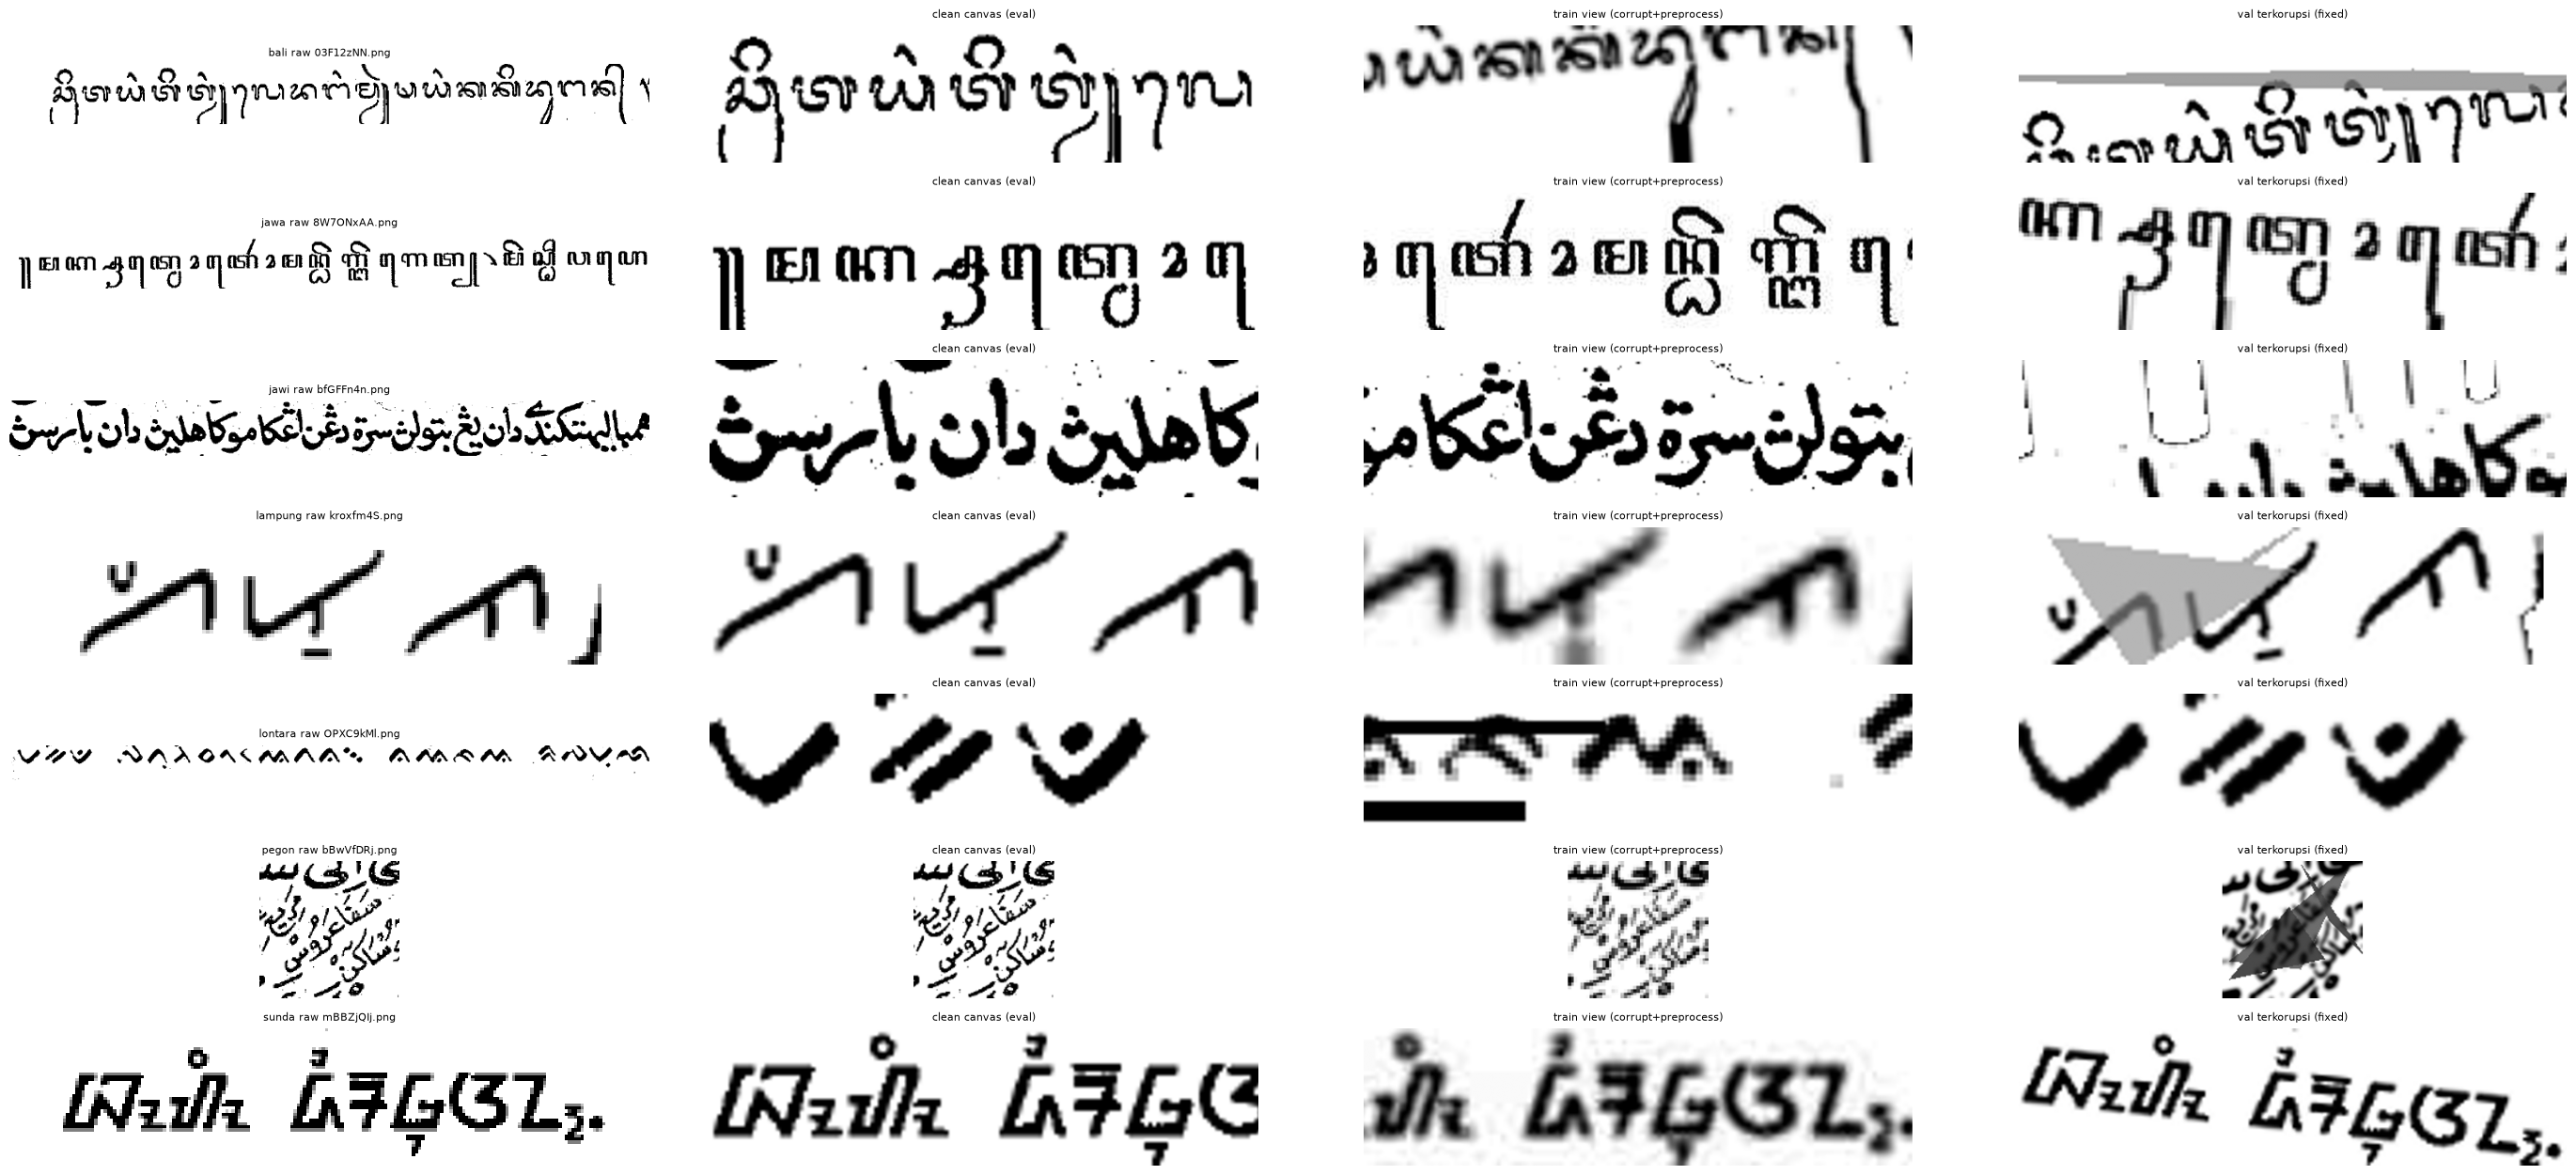

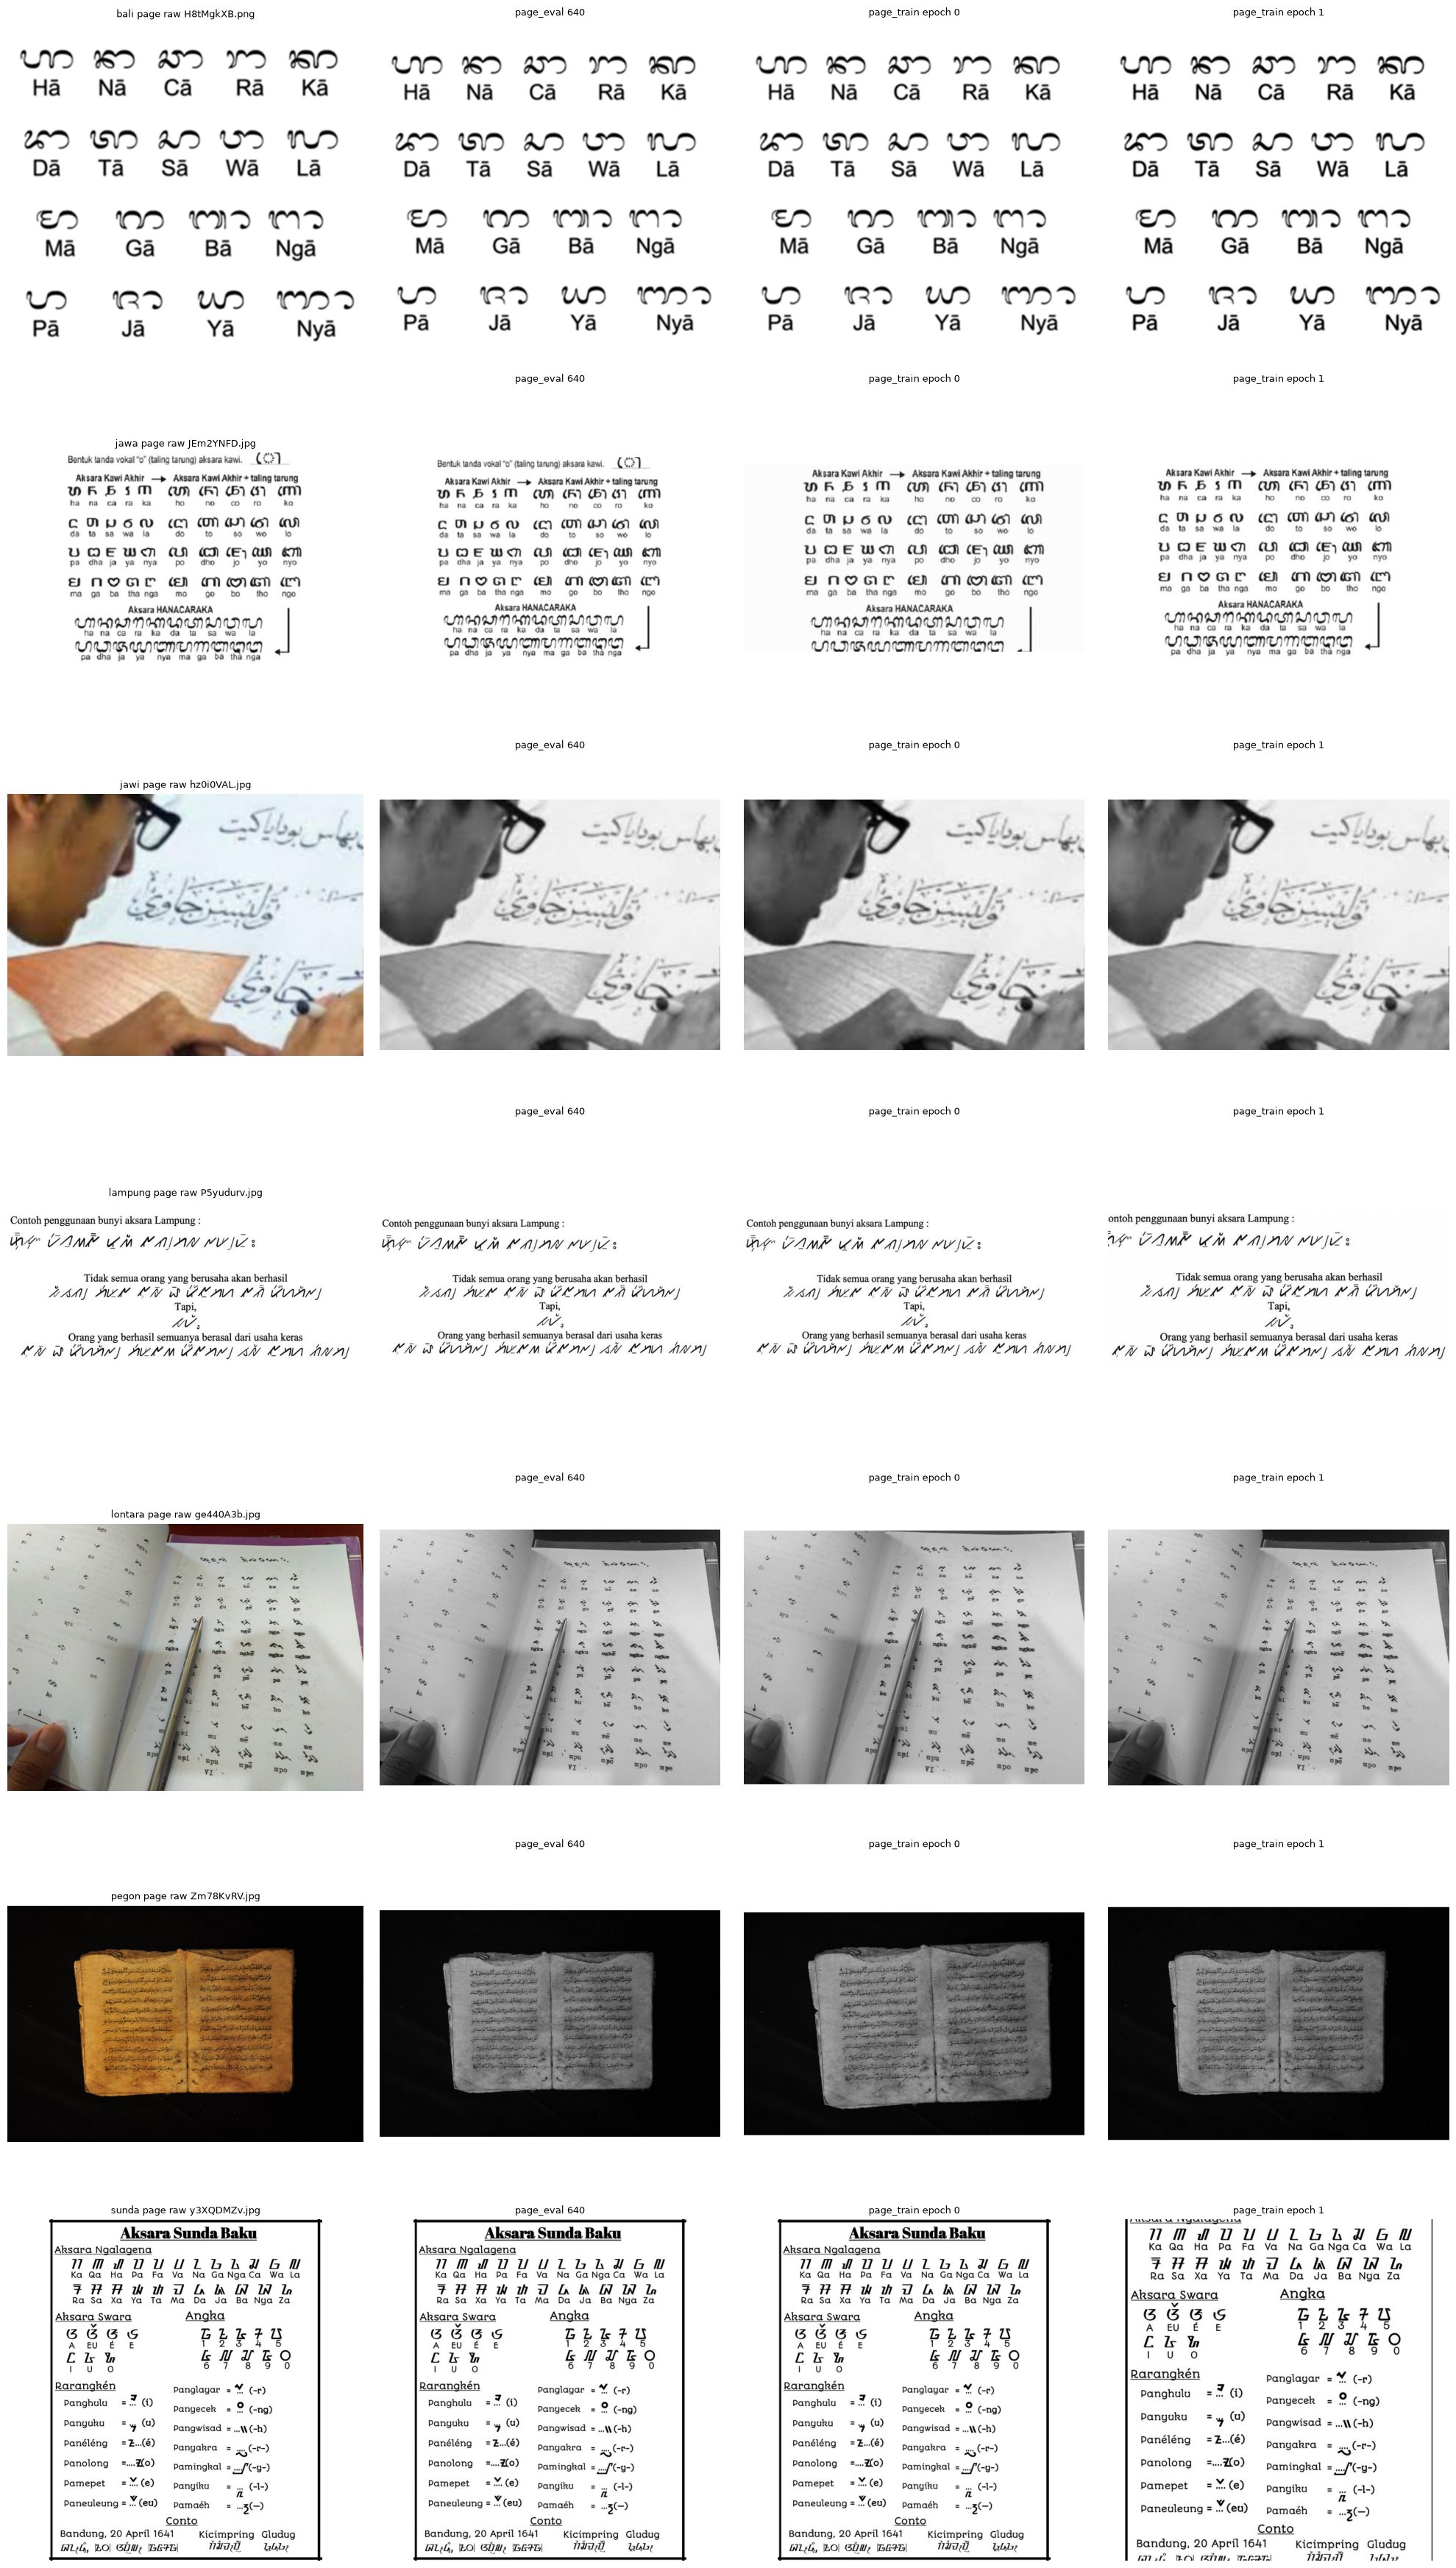

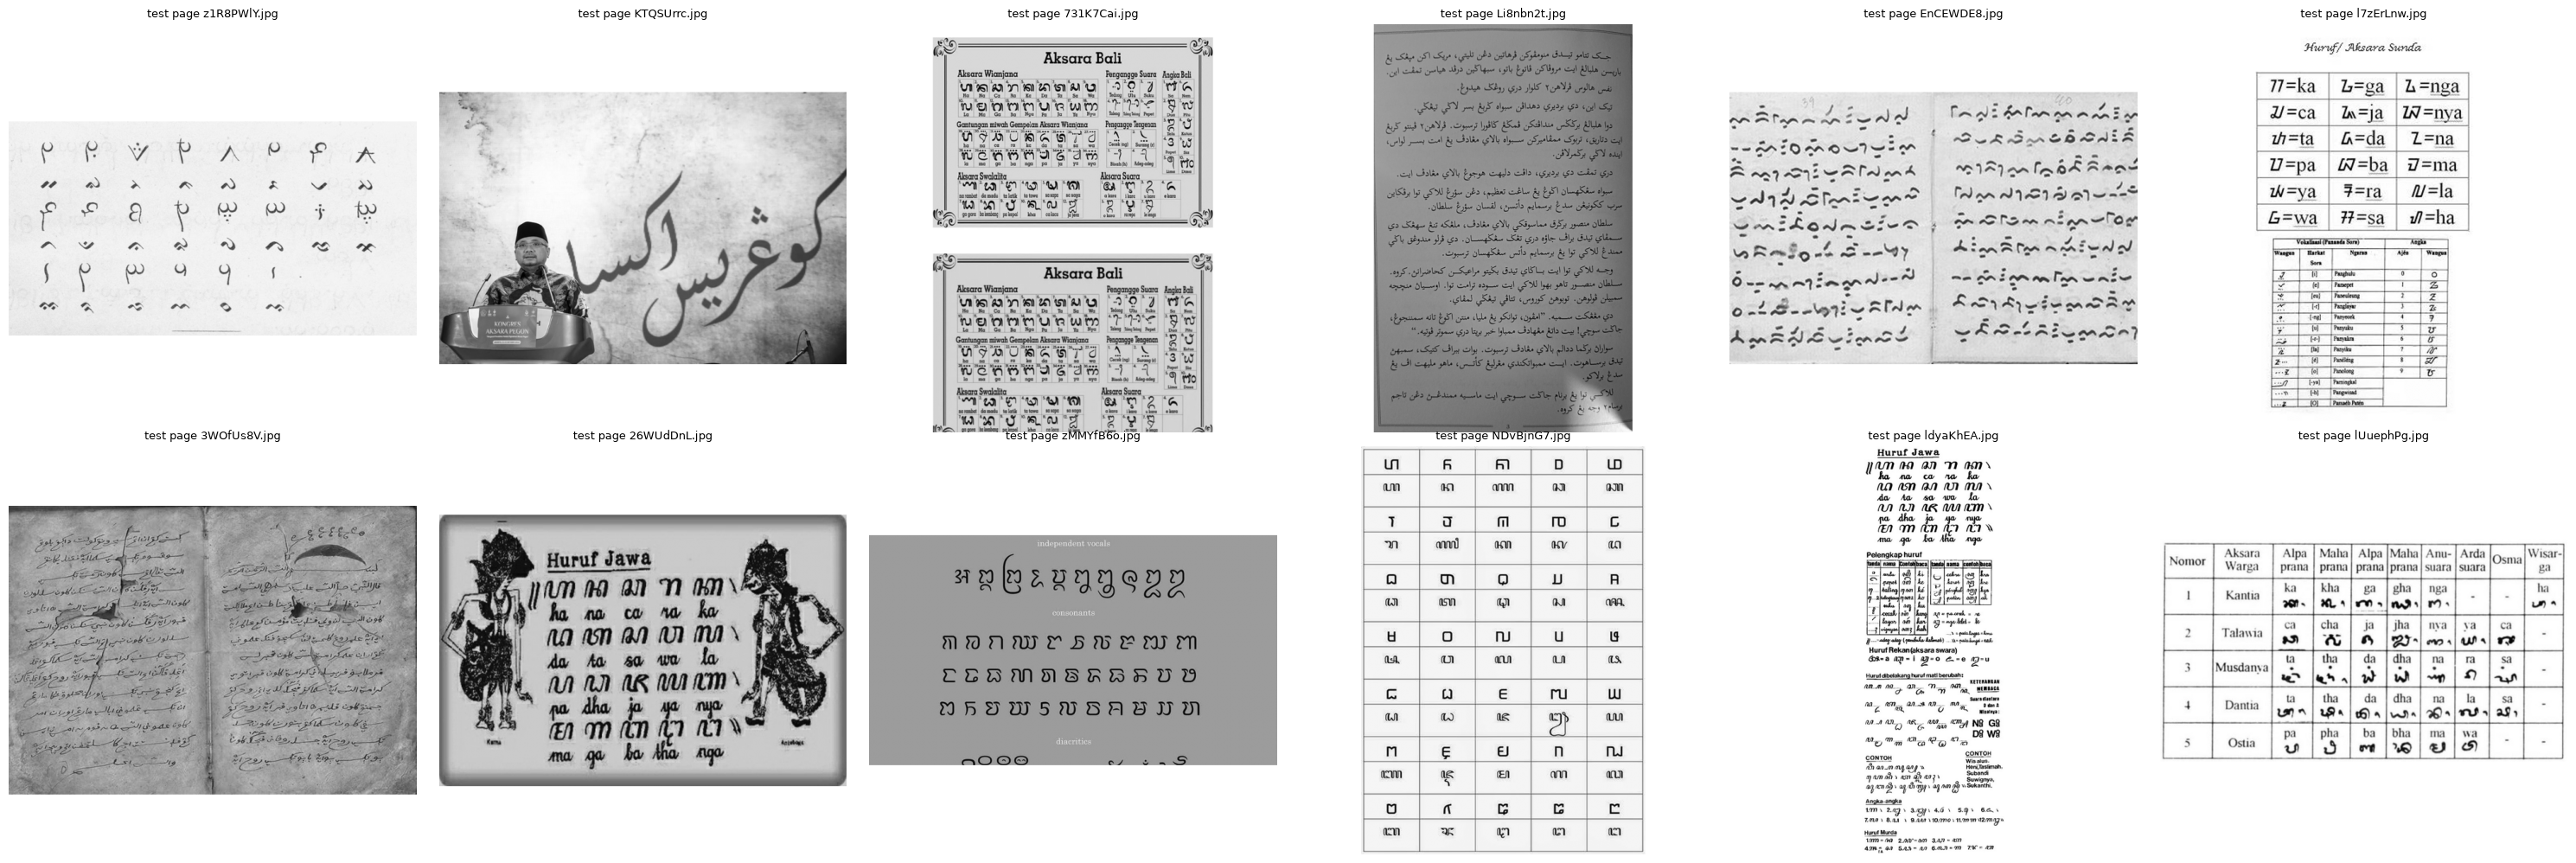

train clean  n=14481 ink median=0.143  blank(<0.5%)=0.01%  >50% black=0.23%  mean grey=215.2
val corrupt  n=13655 ink median=0.145  blank(<0.5%)=0.09%  >50% black=0.54%  mean grey=212.8
test         n= 3121 ink median=0.179  blank(<0.5%)=0.06%  >50% black=3.36%  mean grey=202.3
train page   n=  199 ink median=0.088  blank(<0.5%)=1.01%  >50% black=8.54%  mean grey=202.3
test page    n=  300 ink median=0.085  blank(<0.5%)=0.33%  >50% black=4.33%  mean grey=204.5
sampler fold0: 221 micro-batch (177 non-page x16, 44 page x4)


In [7]:
# visual check 1: non-page seperti v2 (raw | clean canvas | train view | val terkorupsi)
ds_vis = TrainDS(np.arange(len(train)))
fig, axes = plt.subplots(len(LABELS), 4, figsize=(28, 1.8 * len(LABELS)))
for r, lab in enumerate(LABELS):
    j = train.index[(train.label == lab) & ~train_is_page].to_series().sample(1, random_state=r).iloc[0]
    row = axes[r]; x, _ = ds_vis[j]
    row[0].imshow(train_raw[j]); row[0].set_title(f'{lab} raw {train.image_id[j]}', fontsize=8)
    row[1].imshow(clean_tiles[clean_owner == j][0], cmap='gray', vmin=0, vmax=255); row[1].set_title('clean canvas (eval)', fontsize=8)
    row[2].imshow(x[0], cmap='gray', vmin=0, vmax=255); row[2].set_title('train view (corrupt+preprocess)', fontsize=8)
    row[3].imshow(cor_tiles[cor_owner == j][0], cmap='gray', vmin=0, vmax=255); row[3].set_title('val terkorupsi (fixed)', fontsize=8)
    for a in row: a.axis('off')
plt.tight_layout(); plt.savefig(OUT / 'samples_train_nonpage.png', dpi=60); plt.show(); plt.close(fig)

# visual check 2: page per kelas (raw | page_eval | 2x page_train)
fig, axes = plt.subplots(len(LABELS), 4, figsize=(20, 5 * len(LABELS)))
for r, lab in enumerate(LABELS):
    j = train.index[(train.label == lab) & train_is_page].to_series().sample(1, random_state=r).iloc[0]
    row = axes[r]
    row[0].imshow(train_raw[j]); row[0].set_title(f'{lab} page raw {train.image_id[j]}', fontsize=9)
    row[1].imshow(train_page[train_page_owner == j][0], cmap='gray', vmin=0, vmax=255); row[1].set_title(f'page_eval {PAGE_S}', fontsize=9)
    for c in range(2):
        ds_vis.epoch = c
        row[2 + c].imshow(ds_vis[j][0][0], cmap='gray', vmin=0, vmax=255); row[2 + c].set_title(f'page_train epoch {c}', fontsize=9)
    for a in row: a.axis('off')
ds_vis.epoch = 0
plt.tight_layout(); plt.savefig(OUT / 'samples_train_page.png', dpi=50); plt.show(); plt.close(fig)

fig, axes = plt.subplots(2, 6, figsize=(30, 10))
for a, k in zip(axes.ravel(), np.random.default_rng(0).choice(len(test_page), 12, replace=False)):
    a.imshow(test_page[k], cmap='gray', vmin=0, vmax=255); a.set_title(f'test page {test.image_id[test_page_owner[k]]}', fontsize=9); a.axis('off')
plt.tight_layout(); plt.savefig(OUT / 'samples_test_page.png', dpi=45); plt.show(); plt.close(fig)

ink = lambda t: (t < 128).mean(axis=(1, 2))
for name, t in [('train clean', clean_tiles), ('val corrupt', cor_tiles), ('test', test_tiles), ('train page', train_page), ('test page', test_page)]:
    f = ink(t)
    print(f'{name:12s} n={len(t):5d} ink median={np.median(f):.3f}  blank(<0.5%)={np.mean(f < .005):.2%}  >50% black={np.mean(f > .5):.2%}  mean grey={t.mean():.1f}')
smp = MixedBatchSampler(np.where(train.fold != 0)[0], seed=SEED)
print(f'sampler fold0: {len(smp)} micro-batch ({smp.n_np} non-page x{MICRO_BATCH}, {smp.n_pg} page x{PAGE_MB})')
assert x.shape == (1, H, W) and x.dtype == torch.uint8 and ds_vis[int(train_page_owner[0])][0].shape == (1, PAGE_S, PAGE_S)

## Model, optimizer, training per fold

In [8]:
def make_model():
    # dynamic_img_size: DINOv3 memakai RoPE -> 160x640 dan 640x640 dilayani model yang sama tanpa interpolasi pos-embed
    m = timm.create_model(MODEL_NAME, pretrained=True, num_classes=len(LABELS), img_size=(H, W), global_pool='token', dynamic_img_size=True)
    if GRAD_CKPT:
        m.set_grad_checkpointing(True)
    return m.to(DEVICE)


def make_optimizer(model):
    head_ids = {id(p) for p in model.get_classifier().parameters()}
    groups = param_groups_layer_decay(model, weight_decay=WEIGHT_DECAY, layer_decay=LAYER_DECAY, no_weight_decay_list=model.no_weight_decay())
    for g in groups:
        g['params'] = [p for p in g['params'] if id(p) not in head_ids]
    groups = [g for g in groups if g['params']]
    groups.append({'params': list(model.get_classifier().parameters()), 'weight_decay': WEIGHT_DECAY, 'lr_scale': HEAD_LR / BASE_LR})
    for g in groups:
        g['base_lr'] = BASE_LR * g.get('lr_scale', 1.0); g['lr'] = g['base_lr']
    assert sum(p.numel() for g in groups for p in g['params']) == sum(p.numel() for p in model.parameters())
    return torch.optim.AdamW(groups, lr=BASE_LR, fused=True)


def macro_f1(y, logits):
    return f1_score(y, logits.argmax(1), labels=list(range(len(LABELS))), average='macro', zero_division=0)


def val_groups(va_idx, corrupt):
    t, o = (cor_tiles, cor_owner) if corrupt else (clean_tiles, clean_owner)
    return [subset_tiles(t, o, va_idx), subset_tiles(train_page, train_page_owner, va_idx)]  # page val selalu bersih (page test bersih, eda/23)


def run_fold(k):
    tag = f'fold{k}'
    done = OUT / f'{tag}_test_logits.npy'
    if done.exists():
        print(f'{tag}: sudah selesai, skip (hapus {done.name} untuk ulang)'); return
    tr_idx, va_idx = np.where(train.fold != k)[0], np.where(train.fold == k)[0]
    seed_all(SEED + k)
    model, t_start = make_model(), time.time()
    opt = make_optimizer(model)
    counts = np.bincount(y_all[tr_idx], minlength=len(LABELS))
    cw = 1 / np.sqrt(counts); cw = cw / cw.mean()
    crit = nn.CrossEntropyLoss(weight=torch.tensor(cw, dtype=torch.float32, device=DEVICE), label_smoothing=LABEL_SMOOTHING)
    sampler = MixedBatchSampler(tr_idx, seed=SEED * 100 + k)
    steps_per_epoch = len(sampler) // ACCUM
    total, warm = EPOCHS * steps_per_epoch, WARMUP_EPOCHS * steps_per_epoch
    def lr_factor(step):
        if step < warm:
            return (step + 1) / warm
        return 0.01 + 0.99 * 0.5 * (1 + math.cos(math.pi * min(1.0, (step - warm) / max(1, total - warm))))
    vc, vx, y_va = val_groups(va_idx, False), val_groups(va_idx, True), y_all[va_idx]
    va_page = train_is_page[va_idx]
    ds = TrainDS(tr_idx, seed=SEED)
    best, best_state, stale, step, hist = -1.0, None, 0, 0, []
    torch.cuda.reset_peak_memory_stats()
    for epoch in range(EPOCHS):
        ds.epoch = sampler.epoch = epoch
        loader = DataLoader(ds, batch_sampler=sampler, num_workers=NUM_WORKERS, pin_memory=True, prefetch_factor=4)
        model.train(); opt.zero_grad(set_to_none=True)
        t0, loss_sum, seen, pg_loss, pg_n = time.time(), 0.0, 0, 0.0, 0
        for it, (x, y) in enumerate(loader, 1):
            is_pg = x.shape[-2] != H
            x, y = gpu_norm(x.to(DEVICE, non_blocking=True)), y.to(DEVICE, non_blocking=True)
            with torch.autocast('cuda', dtype=torch.bfloat16):
                logits = model(x)
            loss = crit(logits.float(), y)
            assert torch.isfinite(loss), f'loss non-finite {tag} epoch {epoch} iter {it}'
            (loss / ACCUM).backward()
            if it % ACCUM == 0:
                for g in opt.param_groups:
                    g['lr'] = g['base_lr'] * lr_factor(step)
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                opt.step(); opt.zero_grad(set_to_none=True); step += 1
            loss_sum += loss.item() * len(y); seen += len(y)
            if is_pg:
                pg_loss += loss.item() * len(y); pg_n += len(y)
        lc = predict_logits(model, vc, len(va_idx)); lx = predict_logits(model, vx, len(va_idx))
        rec = dict(fold=k, epoch=epoch + 1, loss=loss_sum / seen, page_loss=pg_loss / max(1, pg_n), f1_clean=macro_f1(y_va, lc), f1_corrupt=macro_f1(y_va, lx),
                   page_acc=float((lc.argmax(1)[va_page] == y_va[va_page]).mean()), nonpage_acc_corrupt=float((lx.argmax(1)[~va_page] == y_va[~va_page]).mean()),
                   train_s=round(time.time() - t0), imgs_per_s=round(seen / (time.time() - t0)), lr_top=BASE_LR * lr_factor(step))
        hist.append(rec); print(json.dumps(rec), flush=True)
        if rec['f1_corrupt'] > best:  # v2 rule; f1_corrupt = non-page terkorupsi + page bersih = mirip test
            best, stale = rec['f1_corrupt'], 0
            best_state = {n: v.detach().to('cpu', copy=True) for n, v in model.state_dict().items()}
            best_logits, best_epoch = (lc, lx), epoch + 1
        else:
            stale += 1
            if stale >= PATIENCE:
                print(f'early stop {tag} epoch {epoch + 1}'); break
    model.load_state_dict(best_state)
    np.save(OUT / f'{tag}_val_idx.npy', va_idx)
    np.save(OUT / f'{tag}_oof_clean_logits.npy', best_logits[0]); np.save(OUT / f'{tag}_oof_corrupt_logits.npy', best_logits[1])
    pd.DataFrame(hist).to_csv(OUT / f'{tag}_history.csv', index=False)
    np.save(done, predict_logits(model, [(test_tiles, test_owner), (test_page, test_page_owner)], len(test)))  # ditulis terakhir = penanda selesai
    print(f'{tag}: best f1_corrupt={best:.4f} @{best_epoch} | {(time.time() - t_start) / 60:.1f} min | peak VRAM {torch.cuda.max_memory_allocated() / 2**30:.1f} GB')
    del model, opt, best_state
    gc.collect(); torch.cuda.empty_cache()

In [9]:
for k in FOLDS:
    run_fold(k)

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.21GB            

model.safetensors: downloading bytes:           |  0.00B            

{"fold": 0, "epoch": 1, "loss": 1.3116538413661591, "page_loss": 1.4502738416194916, "f1_clean": 0.9570535254809404, "f1_corrupt": 0.9493468855104812, "page_acc": 0.7586206896551724, "nonpage_acc_corrupt": 0.9627586206896551, "train_s": 44, "imgs_per_s": 69, "lr_top": 4e-05}
{"fold": 0, "epoch": 2, "loss": 0.5272415526449046, "page_loss": 0.5940129844979807, "f1_clean": 0.9858866450969266, "f1_corrupt": 0.9815614241103565, "page_acc": 0.896551724137931, "nonpage_acc_corrupt": 0.9862068965517241, "train_s": 43, "imgs_per_s": 70, "lr_top": 3.919796087756705e-05}
{"fold": 0, "epoch": 3, "loss": 0.5086313661267149, "page_loss": 0.5997711623256857, "f1_clean": 0.9780463953841227, "f1_corrupt": 0.9746164193261274, "page_acc": 0.7931034482758621, "nonpage_acc_corrupt": 0.9848275862068966, "train_s": 43, "imgs_per_s": 70, "lr_top": 3.685681995005739e-05}
{"fold": 0, "epoch": 4, "loss": 0.500846002369802, "page_loss": 0.5065551190213724, "f1_clean": 0.9841676811300647, "f1_corrupt": 0.983090019

## OOF: v5 vs v2 per tipe konten
Angka yang relevan untuk keputusan: **page_acc (bersih)**, karena itu yang berubah. Non-page seharusnya setara v2 (pipeline sama). Catatan `eda/14`: noise page per fold ±.03, dan CV page belum tentu sejalan dengan LB, jadi keputusan final tetap lewat LB.

,run,f1_clean,f1_corrupt,f1_testlike,page_acc,line_acc,block_acc,glyph_acc
0,v5,0.9855,0.9798,0.9798,0.8643,0.9915,0.9682,0.9789


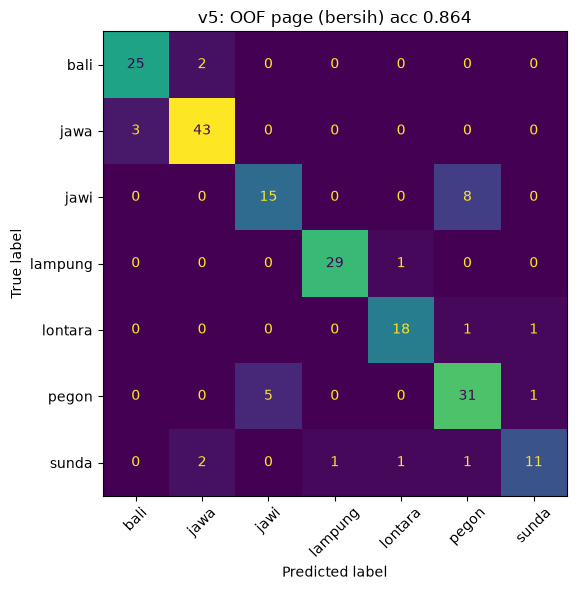

,epoch,loss,page_loss,f1_clean,f1_corrupt,page_acc,nonpage_acc_corrupt,train_s,imgs_per_s,lr_top
fold,,,,,,,,,,
0,7.0,0.4932,0.4645,0.9880,0.9873,0.8621,0.9931,43.0,69.0,0.0
1,4.0,0.4942,0.4738,0.9828,0.9748,0.8491,0.9857,43.0,70.0,0.0
2,8.0,0.4844,0.4787,0.9912,0.9822,0.9412,0.9834,43.0,70.0,0.0
3,9.0,0.4718,0.4523,0.9849,0.9793,0.8298,0.9915,44.0,70.0,0.0
4,9.0,0.4759,0.4502,0.9802,0.9752,0.8611,0.9847,43.0,70.0,0.0


In [10]:
def ctype_of(p):
    w, h = orig_size(p)
    return 'page' if h >= 250 else ('line' if w / h >= 2 else ('block' if w >= 80 else 'glyph'))
ctype = np.array([ctype_of(p) for p in train.path])
done_folds = [k for k in FOLDS if (OUT / f'fold{k}_test_logits.npy').exists()]
assert done_folds, 'belum ada fold selesai'
sm = lambda a: torch.softmax(torch.from_numpy(a), 1).numpy()


def load_oof(d):
    idx = np.concatenate([np.load(d / f'fold{k}_val_idx.npy') for k in done_folds])
    return idx, np.concatenate([np.load(d / f'fold{k}_oof_clean_logits.npy') for k in done_folds]), np.concatenate([np.load(d / f'fold{k}_oof_corrupt_logits.npy') for k in done_folds])


runs = {'v5': load_oof(OUT)}
V2 = ROOT / 'results/v2/main'
if all((V2 / f'fold{k}_oof_clean_logits.npy').exists() for k in done_folds):
    runs['v2'] = load_oof(V2)
rows = []
for name, (idx, lc, lx) in runs.items():
    y, ct = y_all[idx], ctype[idx]
    tl = np.where((ct == 'page')[:, None], lc, lx)  # mirip test: page bersih, sisanya terkorupsi
    r = dict(run=name, f1_clean=macro_f1(y, lc), f1_corrupt=macro_f1(y, lx), f1_testlike=macro_f1(y, tl))
    for t in ['page', 'line', 'block', 'glyph']:
        m = ct == t
        r[f'{t}_acc'] = (tl.argmax(1)[m] == y[m]).mean()
    rows.append(r)
oof_tab = pd.DataFrame(rows).round(4); display(oof_tab); oof_tab.to_csv(OUT / 'oof_by_type.csv', index=False)
idx, lc, lx = runs['v5']; m = ctype[idx] == 'page'
fig, ax = plt.subplots(1, len(runs), figsize=(8 * len(runs), 6), squeeze=False)
for a, (name, (i2, c2, _)) in zip(ax[0], runs.items()):
    mm = ctype[i2] == 'page'
    ConfusionMatrixDisplay(confusion_matrix(y_all[i2][mm], c2.argmax(1)[mm], labels=range(len(LABELS))), display_labels=LABELS).plot(ax=a, xticks_rotation=45, colorbar=False)
    a.set_title(f'{name}: OOF page (bersih) acc {(c2.argmax(1)[mm] == y_all[i2][mm]).mean():.3f}')
plt.tight_layout(); plt.savefig(OUT / 'oof_page_confusion.png', dpi=80); plt.show(); plt.close(fig)
display(pd.concat([pd.read_csv(OUT / f'fold{k}_history.csv') for k in done_folds]).groupby('fold').apply(lambda h: h.loc[h.f1_corrupt.idxmax()]).round(4))

## Submission A (v5 penuh) dan B (hybrid: non-page v2, page v5)
Selisih baris terhadap v2 dicetak per tipe, supaya selisih LB bisa dibaca dengan `eda/12_lb_forensics.py`. Kalau B > v2 di LB, efek page view terbukti; A vs B menunjukkan efek training gabungan pada non-page.

In [11]:
test_ctype = np.array([ctype_of(p) for p in test.path])
p5 = np.mean([sm(np.load(OUT / f'fold{k}_test_logits.npy')) for k in done_folds], 0)
assert p5.shape == (len(test), len(LABELS)) and np.allclose(p5.sum(1), 1)


def write(p, name):
    pred = np.array(LABELS, dtype=object)[p.argmax(1)]
    if USE_TWINS and len(twins):
        tw = test.image_id.map(twins.set_index('image_id').train_label); m = tw.notna().values
        pred[m] = tw[m].values
    sub = sample_sub[['image_id']].merge(pd.DataFrame({'image_id': test.image_id, 'label': pred}), on='image_id', how='left')
    assert len(sub) == len(sample_sub) and sub.label.notna().all() and set(sub.label) <= set(LABELS)
    sub.to_csv(OUT / name, index=False)
    pd.DataFrame(p, columns=LABELS).assign(image_id=test.image_id.values).to_csv(OUT / name.replace('submission', 'probs'), index=False)
    return sub.set_index('image_id').label.reindex(test.image_id).values


subs = {'A_v5': write(p5, 'submission_A_v5.csv')}
v2_m = [V2 / f'fold{k}_test_logits.npy' for k in range(5)]  # selalu 5 fold v2 (= submission LB 0.91514), terlepas dari FOLDS
if all(p.exists() for p in v2_m):
    p2 = np.mean([sm(np.load(p)) for p in v2_m], 0)
    subs['B_hybrid'] = write(np.where(test_is_page[:, None], p5, p2), 'submission_B_hybrid.csv')
for v, p in [('v2_LB0.915', V2 / 'submission.csv'), ('v3_LB0.891', ROOT / 'results/v3/main/submission.csv')]:
    if p.exists():
        subs[v] = pd.read_csv(p).set_index('image_id').label.reindex(test.image_id).values
names = list(subs)
display(pd.DataFrame([[int((subs[a] != subs[b]).sum()) for b in names] for a in names], index=names, columns=names))
if 'v2_LB0.915' in subs:
    for n in [x for x in names if x[0] in 'AB']:
        d = subs[n] != subs['v2_LB0.915']
        print(f'{n} vs v2: {d.sum()} baris beda | per tipe {pd.Series(test_ctype[d]).value_counts().to_dict()}')
        print('   transisi v2 -> ' + n, pd.Series([f'{a}->{b}' for a, b in zip(subs['v2_LB0.915'][d], subs[n][d])]).value_counts().head(10).to_dict())
display(pd.DataFrame({n: pd.Series(subs[n]).value_counts(normalize=True) * 100 for n in names}).reindex(LABELS).round(1))

# grid page yang berubah vs v2 (cek visual, bukan label)
if 'v2_LB0.915' in subs:
    ch = np.where((subs['A_v5'] != subs['v2_LB0.915']) & test_is_page)[0][:40]
    if len(ch):
        fig, axes = plt.subplots(int(np.ceil(len(ch) / 5)), 5, figsize=(25, 4 * int(np.ceil(len(ch) / 5))), squeeze=False)
        for a in axes.ravel(): a.axis('off')
        for a, j in zip(axes.ravel(), ch):
            a.imshow(Image.open(test.path[j]).convert('RGB')); a.set_title(f'v2={subs["v2_LB0.915"][j]} -> v5={subs["A_v5"][j]} ({p5[j].max():.2f})', fontsize=10)
        plt.tight_layout(); plt.savefig(OUT / 'changed_pages.png', dpi=45); plt.show(); plt.close(fig)

config = {k: v for k, v in dict(globals()).items() if k.isupper() and isinstance(v, (int, float, str, bool, list, tuple))}
config.update(torch=torch.__version__, timm=timm.__version__, python=platform.python_version(), gpu=torch.cuda.get_device_name())
(OUT / 'config.json').write_text(json.dumps(config, indent=2, default=str))
print('SELESAI ->', sorted(p.name for p in OUT.glob('submission_*.csv')))

,A_v5
A_v5,0


,A_v5
bali,9.1
jawa,18.1
jawi,14.1
lampung,19.0
lontara,9.1
pegon,16.6
sunda,13.9


SELESAI -> ['submission_A_v5.csv']
